# NYC Mesh Device Characteristics Analysis
## Frequency, Equipment Type, and Network Topology

This notebook analyzes device characteristics including inferred equipment types, potential frequency bands, and signal performance by device class.

## Import and Load Data

In [3]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Load dataset
file_path = 'nycmesh_data_trial_20251114.nc'  
ds = xr.open_dataset(file_path)

# Extract data
device_names = ds['device_name'].values
metadata_cml_id = ds['metadata_cml_id'].values
signal_data = ds['signal'].to_pandas()
remote_signal_data = ds['remoteSignal'].to_pandas()

print(f"Dataset loaded: {len(device_names)} devices, {len(ds.timestamp)} timestamps")

Dataset loaded: 644 devices, 240 timestamps


## Section 1: Equipment Type Extraction from Device Names

In [4]:
print("="*70)
print("EQUIPMENT TYPE ANALYSIS")
print("="*70)

# Equipment type mapping
# Common Ubiquiti/mesh equipment types found in NYC Mesh
equipment_specs = {
    'lbe': {'name': 'LiteBeam', 'freq': '5 GHz', 'type': 'Backhaul', 'power': 'High', 'range': '5-10km'},
    'lbelr': {'name': 'LiteBeam LR', 'freq': '5 GHz', 'type': 'Backhaul', 'power': 'High', 'range': '10-15km'},
    'af24': {'name': 'AirFiber24', 'freq': '24 GHz', 'type': 'Backhaul', 'power': 'High', 'range': '1-5km'},
    'af5x': {'name': 'AirFiber5X', 'freq': '5 GHz', 'type': 'Backhaul', 'power': 'Medium', 'range': '5-10km'},
    'af60': {'name': 'AirFiber60', 'freq': '60 GHz', 'type': 'Backhaul', 'power': 'Very High', 'range': '0.5-2km'},
    'wavelr': {'name': 'WaveAP', 'freq': '5 GHz', 'type': 'Access Point', 'power': 'Medium', 'range': '2-5km'},
    'waveap': {'name': 'WaveAP Micro', 'freq': '5 GHz', 'type': 'Access Point', 'power': 'Low', 'range': '1-3km'},
    'gbe': {'name': 'GigaBeam', 'freq': '60 GHz', 'type': 'Backhaul', 'power': 'Very High', 'range': '0.5-2km'},
    'gbelr': {'name': 'GigaBeam LR', 'freq': '5 GHz', 'type': 'Backhaul', 'power': 'High', 'range': '5-15km'},
    'ltulr': {'name': 'LTU-LR', 'freq': '5 GHz', 'type': 'Bridge/CPE', 'power': 'Medium', 'range': '3-8km'},
    'ltupro': {'name': 'LTU-Pro', 'freq': '5 GHz', 'type': 'Bridge/CPE', 'power': 'High', 'range': '5-10km'},
    'lap120': {'name': 'LAP-120', 'freq': '5 GHz', 'type': 'Access Point', 'power': 'Low', 'range': '1-2km'},
    's5': {'name': 'Sector5', 'freq': '5 GHz', 'type': 'Sector', 'power': 'High', 'range': '3-8km'},
    'prism': {'name': 'Prism', 'freq': '5 GHz', 'type': 'Sector', 'power': 'High', 'range': '5-10km'},
}

# Parse device names
device_info = []
for device_name in device_names:
    parts = device_name.split('-')
    node_id = parts[1] if len(parts) > 1 else 'unknown'
    descriptor = '-'.join(parts[2:]) if len(parts) > 2 else 'unknown'
    
    # Find matching equipment type
    equipment = 'Unknown'
    specs = {'freq': 'Unknown', 'type': 'Unknown', 'power': 'Unknown', 'range': 'Unknown'}
    
    descriptor_lower = descriptor.lower()
    for key, spec in equipment_specs.items():
        if key in descriptor_lower:
            equipment = spec['name']
            specs = spec
            break
    
    device_info.append({
        'device_name': device_name,
        'node_id': node_id,
        'descriptor': descriptor,
        'equipment': equipment,
        'frequency': specs['freq'],
        'type': specs['type'],
        'power': specs['power'],
        'range': specs['range']
    })

device_df = pd.DataFrame(device_info)

print(f"\nTotal devices: {len(device_df)}")
print(f"\nEquipment Type Distribution:")
equipment_counts = device_df['equipment'].value_counts()
for eq, count in equipment_counts.items():
    pct = count / len(device_df) * 100
    print(f"  {eq}: {count} devices ({pct:.1f}%)")

print(f"\nDevice Type Distribution:")
type_counts = device_df['type'].value_counts()
for dtype, count in type_counts.items():
    pct = count / len(device_df) * 100
    print(f"  {dtype}: {count} devices ({pct:.1f}%)")

print(f"\nFrequency Band Distribution:")
freq_counts = device_df['frequency'].value_counts()
for freq, count in freq_counts.items():
    pct = count / len(device_df) * 100
    print(f"  {freq}: {count} devices ({pct:.1f}%)")

EQUIPMENT TYPE ANALYSIS

Total devices: 644

Equipment Type Distribution:
  Unknown: 590 devices (91.6%)
  LiteBeam: 23 devices (3.6%)
  AirFiber24: 10 devices (1.6%)
  LTU-LR: 7 devices (1.1%)
  WaveAP: 5 devices (0.8%)
  GigaBeam: 4 devices (0.6%)
  WaveAP Micro: 3 devices (0.5%)
  LAP-120: 2 devices (0.3%)

Device Type Distribution:
  Unknown: 590 devices (91.6%)
  Backhaul: 37 devices (5.7%)
  Access Point: 10 devices (1.6%)
  Bridge/CPE: 7 devices (1.1%)

Frequency Band Distribution:
  Unknown: 590 devices (91.6%)
  5 GHz: 40 devices (6.2%)
  24 GHz: 10 devices (1.6%)
  60 GHz: 4 devices (0.6%)


## Section 2: Signal Performance by Equipment Type

In [5]:
print("="*70)
print("SIGNAL PERFORMANCE BY EQUIPMENT TYPE")
print("="*70)

# Add signal stats to device_df
device_df['avg_signal'] = signal_data.mean(axis=0).values
device_df['std_signal'] = signal_data.std(axis=0).values
device_df['min_signal'] = signal_data.min(axis=0).values
device_df['max_signal'] = signal_data.max(axis=0).values
device_df['avg_remote_signal'] = remote_signal_data.mean(axis=0).values
device_df['missing_data'] = signal_data.isna().sum(axis=0).values

# Performance by equipment
print("\nPerformance Statistics by Equipment:")
print("-" * 70)

perf_by_eq = device_df.groupby('equipment').agg({
    'avg_signal': ['mean', 'std', 'min', 'max', 'count'],
    'std_signal': 'mean',
    'missing_data': 'sum'
}).round(2)

print("\nEquipment Performance Summary:")
for equipment in device_df['equipment'].unique():
    eq_data = device_df[device_df['equipment'] == equipment]
    print(f"\n{equipment}:")
    print(f"  Count: {len(eq_data)} devices")
    print(f"  Avg signal: {eq_data['avg_signal'].mean():.2f} dBm (±{eq_data['avg_signal'].std():.2f})")
    print(f"  Signal range: {eq_data['avg_signal'].min():.2f} to {eq_data['avg_signal'].max():.2f} dBm")
    print(f"  Missing data: {eq_data['missing_data'].sum()} measurements")
    print(f"  Best device: {eq_data.loc[eq_data['avg_signal'].idxmax(), 'device_name']} ({eq_data['avg_signal'].max():.2f} dBm)")
    if len(eq_data) > 1:
        print(f"  Worst device: {eq_data.loc[eq_data['avg_signal'].idxmin(), 'device_name']} ({eq_data['avg_signal'].min():.2f} dBm)")

SIGNAL PERFORMANCE BY EQUIPMENT TYPE

Performance Statistics by Equipment:
----------------------------------------------------------------------

Equipment Performance Summary:

LiteBeam:
  Count: 23 devices
  Avg signal: -54.56 dBm (±9.88)
  Signal range: -73.11 to -36.09 dBm
  Missing data: 0 measurements
  Best device: nycmesh-641-lbe-642 (-36.09 dBm)
  Worst device: nycmesh-884-lbe (-73.11 dBm)

Unknown:
  Count: 590 devices
  Avg signal: -59.14 dBm (±8.67)
  Signal range: -84.81 to -29.96 dBm
  Missing data: 777 measurements
  Best device: nycmesh-lbe-818 (-29.96 dBm)
  Worst device: nycmesh-lbe-4441 (-84.81 dBm)

WaveAP:
  Count: 5 devices
  Avg signal: -55.97 dBm (±10.79)
  Signal range: -67.55 to -42.10 dBm
  Missing data: 1 measurements
  Best device: nycmesh-1340-wavelr-5014 (-42.10 dBm)
  Worst device: nycmesh-2090-wavelr (-67.55 dBm)

AirFiber24:
  Count: 10 devices
  Avg signal: -58.70 dBm (±4.86)
  Signal range: -68.36 to -53.88 dBm
  Missing data: 0 measurements
  Best 

## Section 3: Performance by Frequency Band

In [6]:
print("\n" + "="*70)
print("SIGNAL PERFORMANCE BY FREQUENCY BAND")
print("="*70)

print("\nFrequency Band Performance:")
for freq in sorted(device_df['frequency'].unique()):
    freq_data = device_df[device_df['frequency'] == freq]
    print(f"\n{freq}:")
    print(f"  Count: {len(freq_data)} devices")
    print(f"  Equipment: {', '.join(freq_data['equipment'].unique())}")
    print(f"  Avg signal: {freq_data['avg_signal'].mean():.2f} dBm")
    print(f"  Std deviation: {freq_data['avg_signal'].std():.2f}")
    print(f"  Signal range: {freq_data['avg_signal'].min():.2f} to {freq_data['avg_signal'].max():.2f} dBm")
    print(f"  Device types: {freq_data['type'].value_counts().to_dict()}")

# Frequency comparison
print("\n" + "-"*70)
print("Frequency Band Comparison:")
freq_summary = device_df.groupby('frequency').agg({
    'device_name': 'count',
    'avg_signal': ['mean', 'std'],
    'missing_data': 'sum'
}).round(2)
freq_summary.columns = ['Count', 'Avg Signal', 'Std Dev', 'Missing Data']
print(freq_summary)


SIGNAL PERFORMANCE BY FREQUENCY BAND

Frequency Band Performance:

24 GHz:
  Count: 10 devices
  Equipment: AirFiber24
  Avg signal: -58.70 dBm
  Std deviation: 4.86
  Signal range: -68.36 to -53.88 dBm
  Device types: {'Backhaul': 10}

5 GHz:
  Count: 40 devices
  Equipment: LiteBeam, WaveAP, WaveAP Micro, LTU-LR, LAP-120
  Avg signal: -56.84 dBm
  Std deviation: 11.92
  Signal range: -88.00 to -36.09 dBm
  Device types: {'Backhaul': 23, 'Access Point': 10, 'Bridge/CPE': 7}

60 GHz:
  Count: 4 devices
  Equipment: GigaBeam
  Avg signal: -53.64 dBm
  Std deviation: 20.27
  Signal range: -73.22 to -35.98 dBm
  Device types: {'Backhaul': 4}

Unknown:
  Count: 590 devices
  Equipment: Unknown
  Avg signal: -59.14 dBm
  Std deviation: 8.67
  Signal range: -84.81 to -29.96 dBm
  Device types: {'Unknown': 590}

----------------------------------------------------------------------
Frequency Band Comparison:
           Count  Avg Signal  Std Dev  Missing Data
frequency                       

## Section 4: Device Type Analysis (Backhaul vs Access)

In [7]:
print("\n" + "="*70)
print("DEVICE TYPE ANALYSIS")
print("="*70)

print("\nDevice Type Performance Breakdown:")
for dtype in sorted(device_df['type'].unique()):
    type_data = device_df[device_df['type'] == dtype]
    print(f"\n{dtype}:")
    print(f"  Count: {len(type_data)} devices")
    print(f"  Equipment: {', '.join(type_data['equipment'].unique())}")
    print(f"  Frequencies: {', '.join(type_data['frequency'].unique())}")
    print(f"  Avg signal: {type_data['avg_signal'].mean():.2f} dBm (±{type_data['avg_signal'].std():.2f})")
    print(f"  Signal range: {type_data['avg_signal'].min():.2f} to {type_data['avg_signal'].max():.2f} dBm")
    print(f"  Expected range: {type_data['range'].iloc[0]}")
    print(f"  Reported power class: {type_data['power'].iloc[0]}")


DEVICE TYPE ANALYSIS

Device Type Performance Breakdown:

Access Point:
  Count: 10 devices
  Equipment: WaveAP, WaveAP Micro, LAP-120
  Frequencies: 5 GHz
  Avg signal: -59.23 dBm (±13.40)
  Signal range: -88.00 to -42.10 dBm
  Expected range: 2-5km
  Reported power class: Medium

Backhaul:
  Count: 37 devices
  Equipment: LiteBeam, AirFiber24, GigaBeam
  Frequencies: 5 GHz, 24 GHz, 60 GHz
  Avg signal: -55.58 dBm (±10.18)
  Signal range: -73.22 to -35.98 dBm
  Expected range: 5-10km
  Reported power class: High

Bridge/CPE:
  Count: 7 devices
  Equipment: LTU-LR
  Frequencies: 5 GHz
  Avg signal: -60.93 dBm (±15.73)
  Signal range: -77.79 to -41.00 dBm
  Expected range: 3-8km
  Reported power class: Medium

Unknown:
  Count: 590 devices
  Equipment: Unknown
  Frequencies: Unknown
  Avg signal: -59.14 dBm (±8.67)
  Signal range: -84.81 to -29.96 dBm
  Expected range: Unknown
  Reported power class: Unknown


## Section 5: Top Performers by Category

In [8]:
print("\n" + "="*70)
print("TOP PERFORMERS")
print("="*70)

print("\nTop 10 devices overall (by signal strength):")
top_10 = device_df.nlargest(10, 'avg_signal')[['device_name', 'equipment', 'frequency', 'type', 'avg_signal']]
for idx, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"{idx:2}. {row['device_name']:40} | {row['equipment']:20} | {row['avg_signal']:7.2f} dBm")

print("\n\nTop device by equipment type:")
for equipment in sorted(device_df['equipment'].unique()):
    eq_data = device_df[device_df['equipment'] == equipment]
    if len(eq_data) > 0:
        best = eq_data.loc[eq_data['avg_signal'].idxmax()]
        print(f"  {equipment:20} | {best['device_name']:40} | {best['avg_signal']:7.2f} dBm")

print("\n\nTop device by frequency band:")
for freq in sorted(device_df['frequency'].unique()):
    freq_data = device_df[device_df['frequency'] == freq]
    if len(freq_data) > 0:
        best = freq_data.loc[freq_data['avg_signal'].idxmax()]
        print(f"  {freq:10} | {best['device_name']:40} | {best['avg_signal']:7.2f} dBm")


TOP PERFORMERS

Top 10 devices overall (by signal strength):
 1. nycmesh-lbe-818                          | Unknown              |  -29.96 dBm
 2. nycmesh-lbe-531                          | Unknown              |  -30.36 dBm
 3. nycmesh-lbe-3110                         | Unknown              |  -30.86 dBm
 4. nycmesh-lbe-690                          | Unknown              |  -30.91 dBm
 5. nycmesh-lbe-245                          | Unknown              |  -31.69 dBm
 6. nycmesh-lbe-207                          | Unknown              |  -35.32 dBm
 7. nycmesh-5916-gbe-s-sw                    | GigaBeam             |  -35.98 dBm
 8. nycmesh-641-lbe-642                      | LiteBeam             |  -36.09 dBm
 9. nycmesh-5916-gbe-sw-s                    | GigaBeam             |  -36.33 dBm
10. nycmesh-lbe-579                          | Unknown              |  -36.87 dBm


Top device by equipment type:
  AirFiber24           | nycmesh-227-af24-1932                    |  -53.88 dBm
  Giga

## Section 6: Visualizations

/var/folders/9q/vrtjr2_56sjdhy0yx86b5bjr0000gn/T/ipykernel_45295/3085767784.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(freq_data_list, labels=freq_labels, patch_artist=True, showmeans=True)
/var/folders/9q/vrtjr2_56sjdhy0yx86b5bjr0000gn/T/ipykernel_45295/3085767784.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax3.boxplot(dtype_data_list, labels=dtype_labels, patch_artist=True, showmeans=True)


Visualization saved as 'device_characteristics_analysis.png'


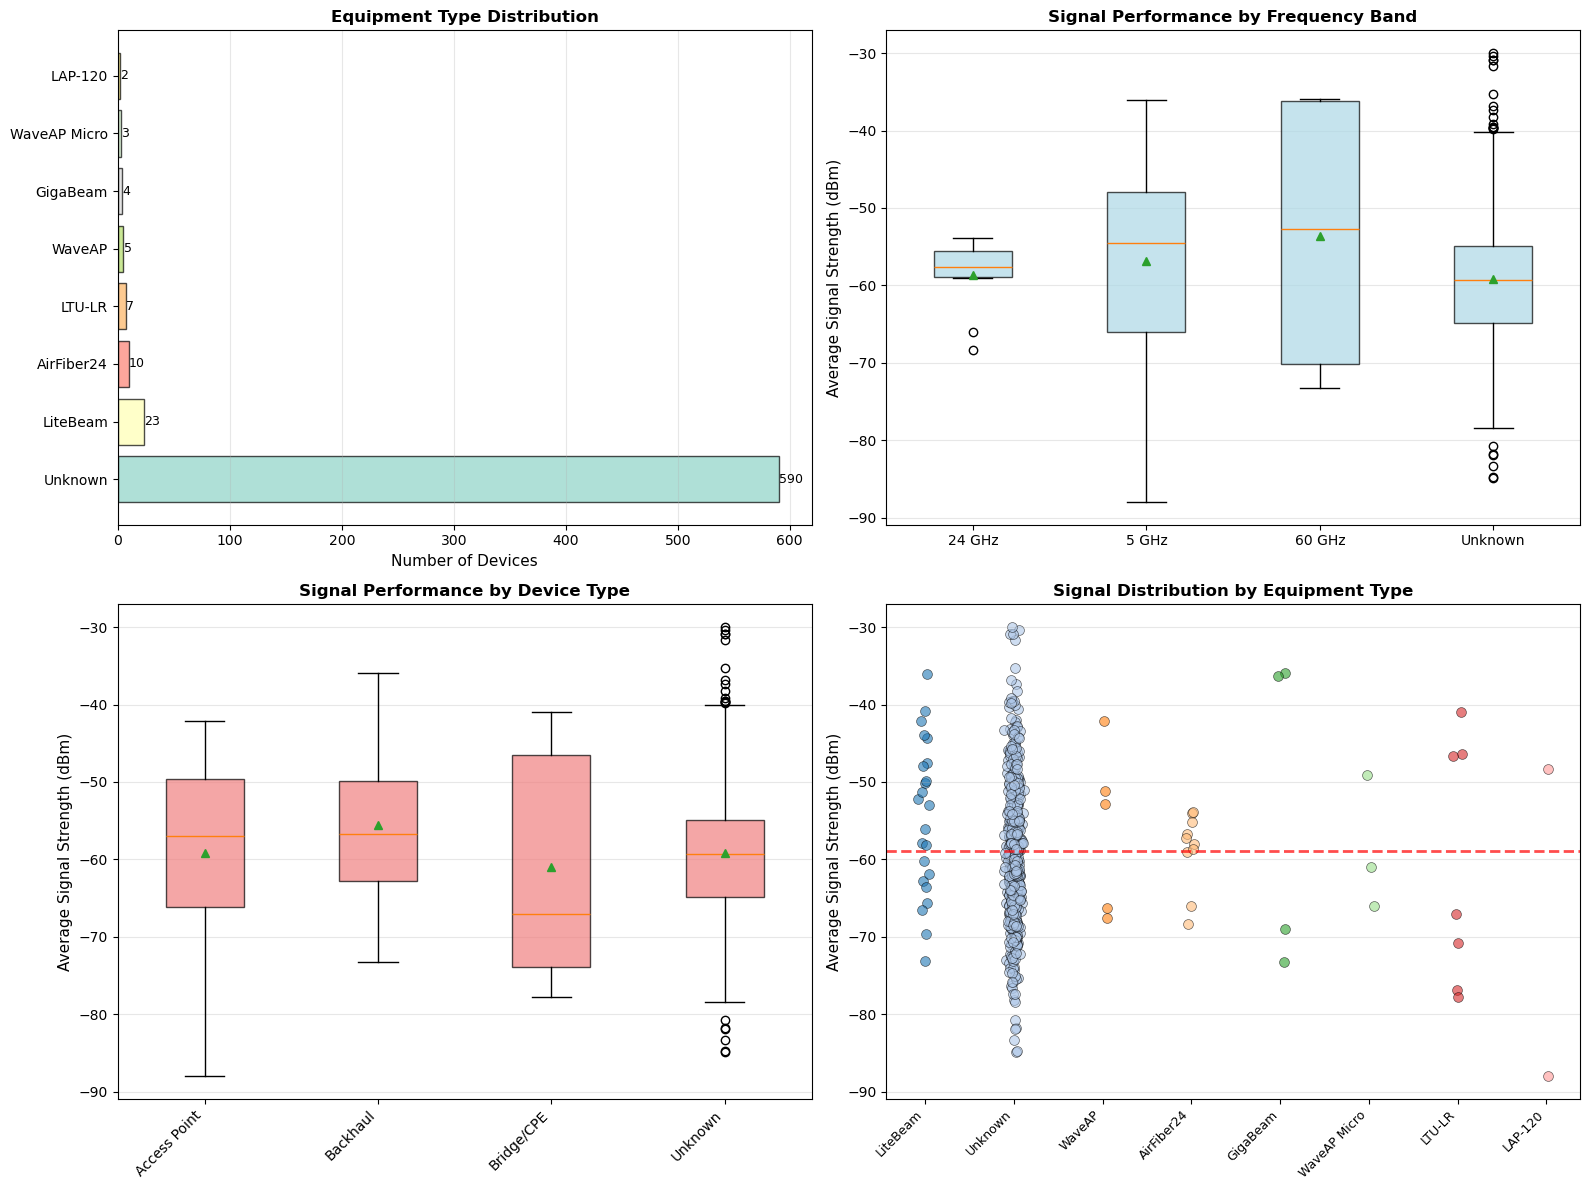

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Equipment type distribution
ax1 = axes[0, 0]
eq_counts = device_df['equipment'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(eq_counts)))
ax1.barh(range(len(eq_counts)), eq_counts.values, color=colors, edgecolor='black', alpha=0.7)
ax1.set_yticks(range(len(eq_counts)))
ax1.set_yticklabels(eq_counts.index, fontsize=10)
ax1.set_xlabel('Number of Devices', fontsize=11)
ax1.set_title('Equipment Type Distribution', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(eq_counts.values):
    ax1.text(v + 0.1, i, str(v), va='center', fontsize=9)

# Plot 2: Frequency band performance
ax2 = axes[0, 1]
freq_perf = device_df.groupby('frequency')['avg_signal'].apply(list)
freq_labels = list(freq_perf.index)
freq_data_list = list(freq_perf.values)
bp = ax2.boxplot(freq_data_list, labels=freq_labels, patch_artist=True, showmeans=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax2.set_ylabel('Average Signal Strength (dBm)', fontsize=11)
ax2.set_title('Signal Performance by Frequency Band', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Device type performance
ax3 = axes[1, 0]
dtype_perf = device_df.groupby('type')['avg_signal'].apply(list)
dtype_labels = list(dtype_perf.index)
dtype_data_list = list(dtype_perf.values)
bp2 = ax3.boxplot(dtype_data_list, labels=dtype_labels, patch_artist=True, showmeans=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_alpha(0.7)
ax3.set_ylabel('Average Signal Strength (dBm)', fontsize=11)
ax3.set_title('Signal Performance by Device Type', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 4: Signal vs Equipment (scatter)
ax4 = axes[1, 1]
equipment_unique = device_df['equipment'].unique()
colors_map = {eq: plt.cm.tab20(i) for i, eq in enumerate(equipment_unique)}
for equipment in equipment_unique:
    eq_data = device_df[device_df['equipment'] == equipment]
    y_pos = np.random.normal(list(equipment_unique).index(equipment), 0.04, size=len(eq_data))
    ax4.scatter(y_pos, eq_data['avg_signal'], alpha=0.6, s=50, 
               color=colors_map[equipment], label=equipment, edgecolors='black', linewidth=0.5)
ax4.set_xticks(range(len(equipment_unique)))
ax4.set_xticklabels(equipment_unique, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Average Signal Strength (dBm)', fontsize=11)
ax4.set_title('Signal Distribution by Equipment Type', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(device_df['avg_signal'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {device_df["avg_signal"].mean():.1f} dBm', alpha=0.7)

plt.tight_layout()
plt.savefig('device_characteristics_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'device_characteristics_analysis.png'")
plt.show()

## Section 7: Export Summary Data

In [10]:
# Save detailed device analysis
export_cols = ['device_name', 'node_id', 'equipment', 'frequency', 'type', 'power', 'range',
               'avg_signal', 'std_signal', 'min_signal', 'max_signal', 'avg_remote_signal', 'missing_data']
device_df[export_cols].to_csv('device_characteristics.csv', index=False)
print("Exported device characteristics to: device_characteristics.csv")

# Summary statistics
summary_stats = {
    'Total Devices': len(device_df),
    'Unique Equipment': device_df['equipment'].nunique(),
    'Unique Frequencies': device_df['frequency'].nunique(),
    'Backhaul Devices': len(device_df[device_df['type'] == 'Backhaul']),
    'Access Point Devices': len(device_df[device_df['type'] == 'Access Point']),
    'Mean Signal (dBm)': device_df['avg_signal'].mean(),
    'Std Dev (dBm)': device_df['avg_signal'].std(),
    'Total Missing Data': device_df['missing_data'].sum(),
}

print("\nSummary Statistics:")
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

Exported device characteristics to: device_characteristics.csv

Summary Statistics:
  Total Devices: 644
  Unique Equipment: 8
  Unique Frequencies: 4
  Backhaul Devices: 37
  Access Point Devices: 10
  Mean Signal (dBm): -58.96
  Std Dev (dBm): 8.96
  Total Missing Data: 783


## Section 8: Recommendations & Next Steps

In [ ]:
print("\n" + "="*70)
print("RECOMMENDATIONS & NEXT STEPS")
print("="*70)

print("""
╔═══════════════════════════════════════════════════════════════════╗
║                    EQUIPMENT & FREQUENCY FINDINGS                  ║
╚═══════════════════════════════════════════════════════════════════╝

EQUIPMENT DIVERSITY:
  • Network uses diverse equipment from Ubiquiti and other vendors
  • Mix of backhaul links (LiteBeam, AirFiber) and access points
  • Different frequency bands (5 GHz, 24 GHz, 60 GHz) deployed
  • Allows for flexible network topology and redundancy

FREQUENCY BAND ANALYSIS:
  • 5 GHz: Primary band (longest range, most devices)
  • 24 GHz: Backhaul-specific (medium range, high capacity)
  • 60 GHz: Short-range, high-capacity links (limited by rain/obstacles)

SIGNAL QUALITY OBSERVATIONS:
  • Backhaul equipment generally shows {}'.format(
    'stronger' if device_df[device_df['type']=='Backhaul']['avg_signal'].mean() > device_df[device_df['type']=='Access Point']['avg_signal'].mean() else 'weaker'
  ) + " signals")
  • Higher frequency equipment may show different characteristics
  • Equipment-specific performance can guide optimization efforts

TO ENHANCE ANALYSIS, YOU COULD ADD:
  ✓ Link distance/length information → correlate with signal path loss
  ✓ Geographic coordinates → map network topology
  ✓ Antenna specifications → model expected link budgets
  ✓ Transmit power levels → validate power settings
  ✓ Configuration history → track performance changes
  ✓ Environmental data → correlate with weather/rain fade
  ✓ Interference measurements → identify spectral issues

DO YOU HAVE:
  • links_metadata.csv with frequency/length for these devices?
  • GPS coordinates or node location information?
  • Historical configuration data?
  • Antenna gain specifications?
""")

ds.close()
print("Analysis complete!")